In [10]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
import random 

import time 

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

# from src.models.dpso_inference import DPSO

from src.data_loader.evaluation_data_generator import DataGenerator
from src.models.odometry2d_ma import sonar_odometry
# from training.utils import pose_err



In [13]:
# Path to root directory
root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
# root_dir = '/content/SonarOdometry'

# Configuration Files
model_config_pth = os.path.join(root_dir, 'config/model2d_aracati.yaml')
sonar_config_pth = os.path.join(root_dir, 'config/sonar_aracati.yaml')

# Path to evaluation dataset
data_root_dir = os.path.join(root_dir, 'SonarOdometryDataset/selfsupervised/val/seq_15')
# data_root_dir = '/content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample/SonarOdometryDataset_sample/seq_15'
# data_root_dir = '/content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample/test_scenarios/seq_2'
# data_root_dir = '/content/drive/MyDrive/Studia/SonarOdometryDataset/aracati2017/aracati2017'


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
            sonar_config = Box(yaml.safe_load(f))

from src.models.utils import ExtrinsicsCalib
extrinsics_calib = ExtrinsicsCalib(T = [sonar_config.position.x, sonar_config.position.y, sonar_config.position.z],
                                   R = [sonar_config.position.roll, sonar_config.position.pitch, sonar_config.position.yaw])

# Import data generator
from src.data_loader.transforms import SonarDatasetTranforms

fls_resolution = (model_config.input_dimensions.polar_height , model_config.input_dimensions.polar_width ) # for own ds
# fls_resolution = (model_config.input_dimensions.cart_height, model_config.input_dimensions.cart_width) # for aracati

data_generator = DataGenerator(data_root_dir, device, fls_resolution=fls_resolution, transforms = SonarDatasetTranforms, calibration = None)
data_lenght = data_generator.get_len()

print(f'Data generator initialized.')
print(f'Data series lenght: {data_lenght}')

# Import model
from src.models.odometry2d_ma import sonar_odometry as sonar_odometry_matchanything
from src.models.odometry2d_new import sonar_odometry as sonar_odometry_loftr

Data generator initialized.
Data series lenght: 1000


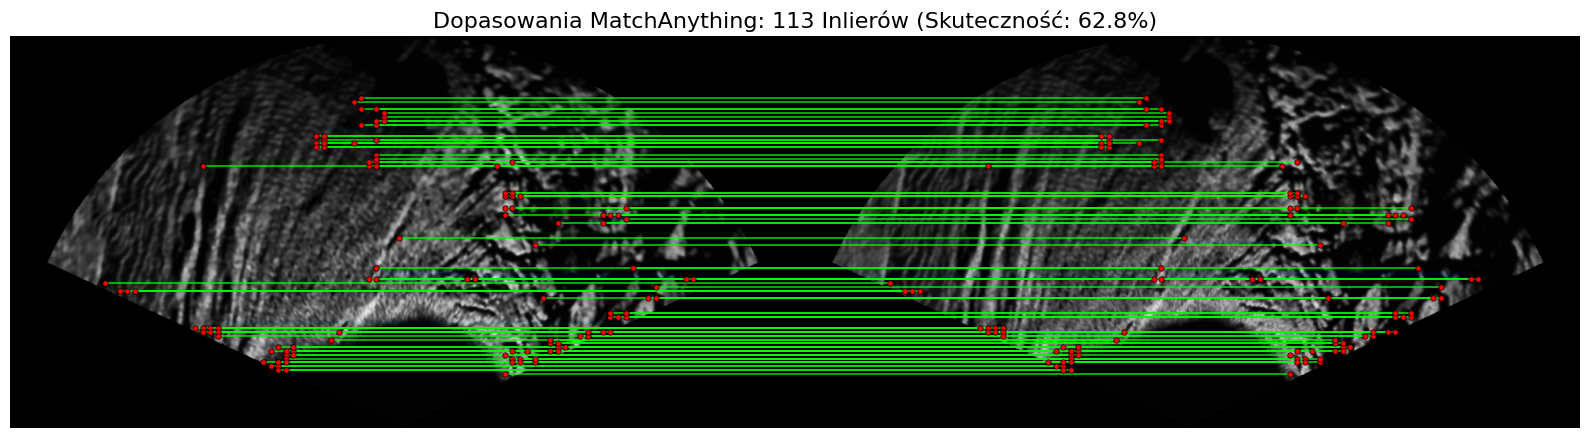

Estymowana poza - X: 0.0035, Y: 0.0003
Estymowany azymut: 0.0000 rad


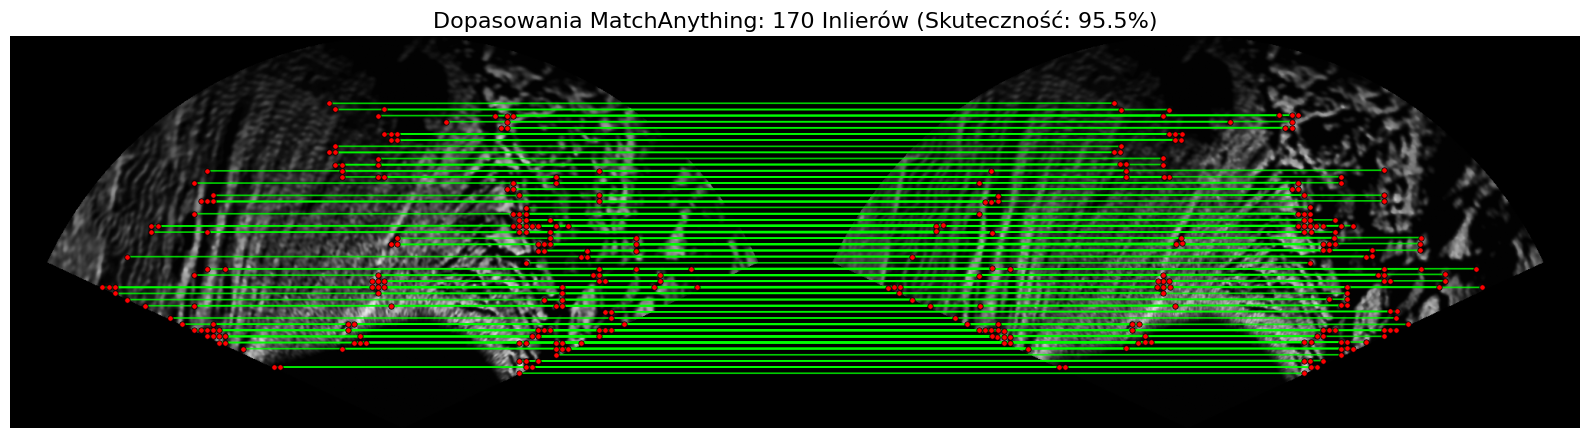

Estymowana poza - X: -0.0131, Y: 0.0122
Estymowany azymut: 0.0006 rad


In [14]:

# 2. Utworzenie instancji modelu odometrii
odometry_model1 = sonar_odometry_matchanything(
    model_config=model_config,
    sonar_config=sonar_config,
    device=device,
    depth_compesation=True,   
    input_img_format='polar',
    ref_frame_orient='sim'
).to(device)

odometry_model2 = sonar_odometry_loftr(
    model_config=model_config,
    sonar_config=sonar_config,
    device=device,
    depth_compesation=True,   
    input_img_format='polar',
    ref_frame_orient='sim'
).to(device)



t1, frame1, pose_gt1, depth1 = data_generator.get_sample(0, return_visu=False, return_depth=True)
t2, frame2, pose_gt2, depth2 = data_generator.get_sample(1, return_visu=False, return_depth=True)


# ----------------------------------------------------
odometry_model1.set_init_state(
    init_x=0.0, 
    init_y=0.0, 
    init_azimuth=0.0, 
    init_frame=frame1.squeeze(0), 
    init_depth=depth1
)

pred_pose, pred_azimuth, visu = odometry_model1(
    frame=frame2.squeeze(0), 
    depth=depth2, 
    return_visu=True
)

if visu is not None:
    plt.figure(figsize=(16, 8))
    
    # Wyświetlamy połączone obrazy (Ref po lewej, New po prawej)
    plt.imshow(visu['combined_imgs'])

    pts1 = visu['pts1']
    pts2 = visu['pts2']
    offset_x = visu['pts2_offset'][1] # Szerokość obrazka, którą musimy dodać do punktów na prawej klatce

    # Rysowanie linii dopasowań (inlierów z RANSAC)
    for p1, p2 in zip(pts1, pts2):
        x1, y1 = p1[0], p1[1]
        x2, y2 = p2[0] + offset_x, p2[1]
        
        # Linie łączące
        plt.plot([x1, x2], [y1, y2], color='lime', linewidth=1.2, alpha=0.8)
        # Kropki na cechach
        plt.scatter([x1, x2], [y1, y2], color='red', s=15, edgecolors='black', linewidth=0.5, zorder=5)

    plt.title(f"Dopasowania MatchAnything: {visu['inliers_abs']} Inlierów (Skuteczność: {visu['inliers_ratio']:.1%})", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"Estymowana poza - X: {pred_pose[0]:.4f}, Y: {pred_pose[1]:.4f}")
    print(f"Estymowany azymut: {pred_azimuth:.4f} rad")
else:
    print("Nie udało się uzyskać danych wizualizacyjnych (za mało punktów dopasowania?).")






# ----------------------------------------------------
odometry_model2.set_init_state(
    init_x=0.0, 
    init_y=0.0, 
    init_azimuth=0.0, 
    init_frame=frame1.squeeze(0), 
    init_depth=depth1
)

pred_pose, pred_azimuth, visu = odometry_model2(
    frame=frame2.squeeze(0), 
    depth=depth2, 
    return_visu=True
)

if visu is not None:
    plt.figure(figsize=(16, 8))
    
    # Wyświetlamy połączone obrazy (Ref po lewej, New po prawej)
    plt.imshow(visu['combined_imgs'])

    pts1 = visu['pts1']
    pts2 = visu['pts2']
    offset_x = visu['pts2_offset'][1] # Szerokość obrazka, którą musimy dodać do punktów na prawej klatce

    # Rysowanie linii dopasowań (inlierów z RANSAC)
    for p1, p2 in zip(pts1, pts2):
        x1, y1 = p1[0], p1[1]
        x2, y2 = p2[0] + offset_x, p2[1]
        
        # Linie łączące
        plt.plot([x1, x2], [y1, y2], color='lime', linewidth=1.2, alpha=0.8)
        # Kropki na cechach
        plt.scatter([x1, x2], [y1, y2], color='red', s=15, edgecolors='black', linewidth=0.5, zorder=5)

    plt.title(f"Dopasowania MatchAnything: {visu['inliers_abs']} Inlierów (Skuteczność: {visu['inliers_ratio']:.1%})", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"Estymowana poza - X: {pred_pose[0]:.4f}, Y: {pred_pose[1]:.4f}")
    print(f"Estymowany azymut: {pred_azimuth:.4f} rad")
else:
    print("Nie udało się uzyskać danych wizualizacyjnych (za mało punktów dopasowania?).")